In [172]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [173]:
root_output_directory = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/hainich"
scenario_name = "broad_local_anet_fix"
input_path = os.path.join(root_output_directory,scenario_name,'input')
output_path = os.path.join(root_output_directory,scenario_name,'output')
post_path = os.path.join(root_output_directory,scenario_name,'post')
if not os.path.exists(post_path):
    os.makedirs(post_path)

In [174]:
df_rmse = xr.open_dataset(os.path.join(output_path,'Sens_Output0.nc')).to_dataframe()
df_rmse

,RMSE_J,RMSE_G,RMSE_psi_stem
run_id,,,
0,0.000326,0.000344,0.282540
1,0.000650,0.000597,0.816400
2,0.000424,0.000507,0.513457
3,0.000348,0.000353,0.133354
4,0.000352,0.000448,0.432261
...,...,...,...
99995,0.000324,0.000414,0.092961
99996,0.000284,0.000402,0.353494
99997,0.000883,0.000866,0.387757


In [175]:
df_s = pd.read_csv(os.path.join(input_path,'Hainich_parameters.csv'))
df_s

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,organic_matter_fracs,theta_r,theta_s,camp_b,pore_size_ind,tree_density,sigma_log_likelyhood,soil_profile_index,theta_emp_multiplier,solver_precision
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,0.05;0.05;0.05,0.08586168;0.08586168;0.08586168,0.49281834;0.49281834;0.49281834,8.4;8.4;8.4,0.48099946;0.48099946;0.48099946,0.006512,1.0,2,1.0,1.000000e-10
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,0.05;0.05;0.05,0.08067507;0.08067507;0.08067507,0.49466736;0.49466736;0.49466736,8.4;8.4;8.4,0.47457851;0.47457851;0.47457851,0.005905,1.0,2,1.0,1.000000e-10
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,0.05;0.05;0.05,0.0975763;0.0975763;0.0975763,0.47958391;0.47958391;0.47958391,8.4;8.4;8.4,0.48617806;0.48617806;0.48617806,0.007877,1.0,2,1.0,1.000000e-10
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,0.05;0.05;0.05,0.09444591;0.09444591;0.09444591,0.49501252;0.49501252;0.49501252,8.4;8.4;8.4,0.47973888;0.47973888;0.47973888,0.004748,1.0,2,1.0,1.000000e-10
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,0.05;0.05;0.05,0.08751528;0.08751528;0.08751528,0.48864499;0.48864499;0.48864499,8.4;8.4;8.4,0.488151;0.488151;0.488151,0.008144,1.0,2,1.0,1.000000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,0.05;0.05;0.05,0.09453837;0.09453837;0.09453837,0.48740273;0.48740273;0.48740273,8.4;8.4;8.4,0.47384432;0.47384432;0.47384432,0.007347,1.0,2,1.0,1.000000e-10
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,0.05;0.05;0.05,0.09875885;0.09875885;0.09875885,0.4972695;0.4972695;0.4972695,8.4;8.4;8.4,0.48379835;0.48379835;0.48379835,0.005787,1.0,2,1.0,1.000000e-10
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,0.05;0.05;0.05,0.09526796;0.09526796;0.09526796,0.47173218;0.47173218;0.47173218,8.4;8.4;8.4,0.48397505;0.48397505;0.48397505,0.007833,1.0,2,1.0,1.000000e-10
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,0.05;0.05;0.05,0.09199038;0.09199038;0.09199038,0.48632224;0.48632224;0.48632224,8.4;8.4;8.4,0.48951306;0.48951306;0.48951306,0.006225,1.0,2,1.0,1.000000e-10


In [176]:
if df_s.shape[0] != df_s.shape[0]:
    print("Error dataframes do not match in size")

In [177]:
df_s['psi_soil_sat0'] = df_s['psi_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['k_soil_sat0'] = df_s['k_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_s0'] = df_s['theta_s'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_r0'] = df_s['theta_r'].str.split(';', expand=True).values[:,0].astype(float)
df_s['pore_0'] = df_s['pore_size_ind'].str.split(';', expand=True).values[:,0].astype(float)

In [178]:
df_d = pd.concat([df_s, df_rmse], axis=1)

In [179]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,theta_emp_multiplier,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,1.0,1.000000e-10,-0.000676,3.230872e-07,0.492818,0.085862,0.480999,0.000326,0.000344,0.282540
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,1.0,1.000000e-10,-0.001985,1.369353e-07,0.494667,0.080675,0.474579,0.000650,0.000597,0.816400
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,1.0,1.000000e-10,-0.001645,2.001595e-07,0.479584,0.097576,0.486178,0.000424,0.000507,0.513457
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,1.0,1.000000e-10,-0.000990,6.440061e-07,0.495013,0.094446,0.479739,0.000348,0.000353,0.133354
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,1.0,1.000000e-10,-0.001989,1.718914e-07,0.488645,0.087515,0.488151,0.000352,0.000448,0.432261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,1.0,1.000000e-10,-0.001567,8.884224e-07,0.487403,0.094538,0.473844,0.000324,0.000414,0.092961
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,1.0,1.000000e-10,-0.001697,2.865913e-07,0.497269,0.098759,0.483798,0.000284,0.000402,0.353494
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,1.0,1.000000e-10,-0.001098,3.153229e-07,0.471732,0.095268,0.483975,0.000883,0.000866,0.387757
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,1.0,1.000000e-10,-0.001515,5.182526e-07,0.486322,0.091990,0.489513,0.000247,0.000343,0.083930


In [180]:
max_rmse_J = 0.000347
max_rmse_psi_stem = 0.0668
df_d['RMSE_com_avg'] = (df_d['RMSE_psi_stem'] / max_rmse_psi_stem + df_d['RMSE_J'] / max_rmse_J) / 2.0;

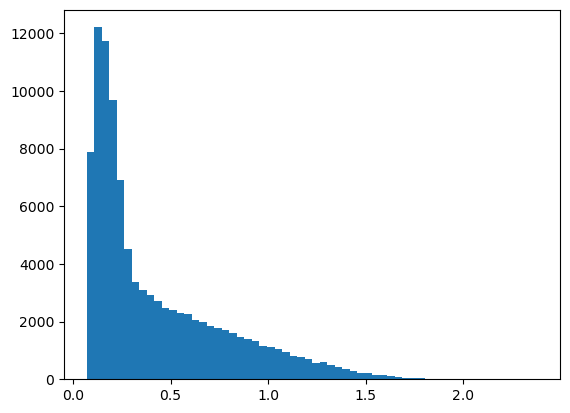

In [181]:
plt.hist(df_d['RMSE_psi_stem'], bins =60);

In [182]:
df_psi_stem = df_d.loc[df_d['RMSE_psi_stem'] < 0.08]
print(df_psi_stem.shape)

(999, 52)


In [189]:
df_J= df_d.loc[df_d['RMSE_J'] < 0.000195]
print(df_J.shape)

(1045, 52)


Text(0.5, 1.0, 'pore_0')

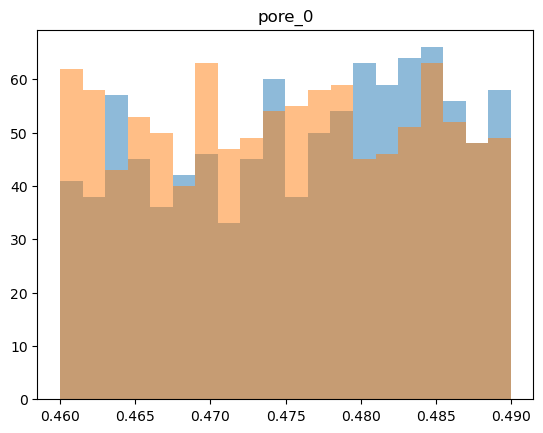

In [190]:
plt.hist(df_psi_stem['pore_0'], alpha = 0.5, bins = 20);
plt.hist(df_J['pore_0'], alpha = 0.5, bins = 20);
plt.title("pore_0")

In [191]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem','leaf_area_index', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'theta_s0', 'pore_0', 'theta_r0', 'anet_max', 'root_area_index', 'tree_density' ]

for var in vars:
    
    if var == 'leaf_hydraulic_capacitance':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    elif var == 'k_soil_sat0':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    else:
        plt.hist(df_psi_stem[var], alpha = 0.5, bins = 20);
        plt.hist(df_J[var], alpha = 0.5, bins = 20);

    plt.title(var)
    plt.savefig(f"{post_path}/hist_{var}.png")
    plt.close()

In [161]:
df_psi_stem

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
22,22,22,1800.0,1800,False,1.0,4.0,Weibull,1.783921,972.935,...,1.000000e-10,-0.001726,2.878166e-07,0.497128,0.088047,0.468093,0.000371,0.000438,0.073610,1.085751
132,132,132,1800.0,1800,False,1.0,4.0,Weibull,2.789624,972.935,...,1.000000e-10,-0.001854,8.137221e-07,0.472699,0.096026,0.469226,0.000334,0.000400,0.077693,1.063075
140,140,140,1800.0,1800,False,1.0,4.0,Weibull,1.671646,972.935,...,1.000000e-10,-0.000660,6.443101e-07,0.489875,0.096632,0.468463,0.000405,0.000468,0.078294,1.169329
156,156,156,1800.0,1800,False,1.0,4.0,Weibull,2.080160,972.935,...,1.000000e-10,-0.000732,4.906533e-07,0.497824,0.085325,0.470450,0.000344,0.000411,0.079187,1.087939
268,268,268,1800.0,1800,False,1.0,4.0,Weibull,1.043422,972.935,...,1.000000e-10,-0.000769,3.083305e-07,0.474799,0.080310,0.473540,0.000263,0.000337,0.070839,0.909114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99532,99532,99532,1800.0,1800,False,1.0,4.0,Weibull,1.966252,972.935,...,1.000000e-10,-0.001810,3.784453e-07,0.479050,0.094332,0.468740,0.000401,0.000480,0.077143,1.155771
99554,99554,99554,1800.0,1800,False,1.0,4.0,Weibull,2.037005,972.935,...,1.000000e-10,-0.000656,1.936034e-07,0.471640,0.081968,0.479817,0.000502,0.000573,0.074735,1.282129
99559,99559,99559,1800.0,1800,False,1.0,4.0,Weibull,1.835271,972.935,...,1.000000e-10,-0.001286,4.155554e-07,0.491588,0.093027,0.478527,0.000324,0.000411,0.076825,1.042315
99838,99838,99838,1800.0,1800,False,1.0,4.0,Weibull,1.175076,972.935,...,1.000000e-10,-0.000684,6.954091e-07,0.497099,0.094232,0.465203,0.000289,0.000347,0.077146,0.993920


In [192]:
best_common = np.intersect1d(df_psi_stem.index, df_J.index)

In [193]:
df_best_c  = df_d.iloc[best_common]
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
18551,18551,18551,1800.0,1800,False,1.0,4.0,Weibull,1.344885,972.935,...,1.000000e-10,-0.001286,2.486256e-07,0.476128,0.080556,0.466796,0.000190,0.000242,0.074984,0.835682
32344,32344,32344,1800.0,1800,False,1.0,4.0,Weibull,1.236336,972.935,...,1.000000e-10,-0.001359,3.640125e-07,0.489206,0.098645,0.467178,0.000193,0.000245,0.078254,0.864321
50688,50688,50688,1800.0,1800,False,1.0,4.0,Weibull,1.288635,972.935,...,1.000000e-10,-0.001644,8.636990e-07,0.493162,0.088033,0.472110,0.000188,0.000242,0.078333,0.857637
83844,83844,83844,1800.0,1800,False,1.0,4.0,Weibull,1.046528,972.935,...,1.000000e-10,-0.000885,2.094693e-07,0.471737,0.081988,0.483661,0.000188,0.000245,0.078184,0.856712


In [194]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,1.000000e-10,-0.000676,3.230872e-07,0.492818,0.085862,0.480999,0.000326,0.000344,0.282540,2.584005
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,1.000000e-10,-0.001985,1.369353e-07,0.494667,0.080675,0.474579,0.000650,0.000597,0.816400,7.046858
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,1.000000e-10,-0.001645,2.001595e-07,0.479584,0.097576,0.486178,0.000424,0.000507,0.513457,4.454529
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,1.000000e-10,-0.000990,6.440061e-07,0.495013,0.094446,0.479739,0.000348,0.000353,0.133354,1.499217
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,1.000000e-10,-0.001989,1.718914e-07,0.488645,0.087515,0.488151,0.000352,0.000448,0.432261,3.743299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,1.000000e-10,-0.001567,8.884224e-07,0.487403,0.094538,0.473844,0.000324,0.000414,0.092961,1.162825
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,1.000000e-10,-0.001697,2.865913e-07,0.497269,0.098759,0.483798,0.000284,0.000402,0.353494,3.054822
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,1.000000e-10,-0.001098,3.153229e-07,0.471732,0.095268,0.483975,0.000883,0.000866,0.387757,4.174910
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,1.000000e-10,-0.001515,5.182526e-07,0.486322,0.091990,0.489513,0.000247,0.000343,0.083930,0.983607


In [195]:
m = 0.9570685625076294

In [196]:
df_best_psi_stem = df_d.sort_values(by='RMSE_psi_stem').iloc[0:30]
df_best_psi_stem.to_csv(f"{input_path}/parameters_best_psi_stem.csv")
df_best_J = df_d.sort_values(by='RMSE_J').iloc[0:30]
df_best_J.to_csv(f"{input_path}/parameters_best_J.csv")
df_best_both = df_d.sort_values(by='RMSE_com_avg').iloc[0:30]
df_best_both.to_csv(f"{input_path}/parameters_best_both.csv")


In [197]:
df_best_both

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
11404,11404,11404,1800.0,1800,False,1.0,4.0,Weibull,1.609777,972.935,...,1.000000e-10,-0.001230,1.791267e-07,0.470296,0.084269,0.464565,0.000197,0.000252,0.072447,0.825621
18551,18551,18551,1800.0,1800,False,1.0,4.0,Weibull,1.344885,972.935,...,1.000000e-10,-0.001286,2.486256e-07,0.476128,0.080556,0.466796,0.000190,0.000242,0.074984,0.835682
84523,84523,84523,1800.0,1800,False,1.0,4.0,Weibull,1.221956,972.935,...,1.000000e-10,-0.001566,1.654373e-07,0.472869,0.082228,0.488494,0.000195,0.000250,0.074787,0.841389
64020,64020,64020,1800.0,1800,False,1.0,4.0,Weibull,1.071543,972.935,...,1.000000e-10,-0.001010,3.901928e-07,0.472473,0.080027,0.478932,0.000213,0.000277,0.071906,0.845303
268,268,268,1800.0,1800,False,1.0,4.0,Weibull,1.043422,972.935,...,1.000000e-10,-0.000769,3.083305e-07,0.474799,0.080310,0.473540,0.000221,0.000274,0.071179,0.851106
52897,52897,52897,1800.0,1800,False,1.0,4.0,Weibull,1.750111,972.935,...,1.000000e-10,-0.000532,4.328867e-07,0.489296,0.095400,0.481930,0.000209,0.000259,0.073686,0.852141
19928,19928,19928,1800.0,1800,False,1.0,4.0,Weibull,1.094753,972.935,...,1.000000e-10,-0.000957,4.059596e-07,0.498997,0.086784,0.480961,0.000212,0.000276,0.073327,0.854474
83844,83844,83844,1800.0,1800,False,1.0,4.0,Weibull,1.046528,972.935,...,1.000000e-10,-0.000885,2.094693e-07,0.471737,0.081988,0.483661,0.000188,0.000245,0.078184,0.856712
58583,58583,58583,1800.0,1800,False,1.0,4.0,Weibull,1.360157,972.935,...,1.000000e-10,-0.001159,4.018387e-07,0.497997,0.089733,0.481202,0.000215,0.000281,0.073157,0.856816
50688,50688,50688,1800.0,1800,False,1.0,4.0,Weibull,1.288635,972.935,...,1.000000e-10,-0.001644,8.636990e-07,0.493162,0.088033,0.472110,0.000188,0.000242,0.078333,0.857637


In [109]:
df_best_both.describ

,Unnamed: 0,id,dts,dts_input,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,anet_max,sw_rad_max,root_area_index,canopy_height,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
count,30.000000,30.000000,30.0,30.0,30.0,30.0,30.000000,3.000000e+01,30.000000,30.0,...,3.000000e+01,30.000000,3.000000e+01,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,50135.700000,50135.700000,1800.0,1800.0,1.0,4.0,1.712195,9.729350e+02,8.034165,31.0,...,1.000000e-10,-0.286583,7.231629e-07,0.482850,0.051831,0.410179,0.000264,0.000330,0.073036,0.926715
std,27649.272323,27649.272323,0.0,0.0,0.0,0.0,0.574156,3.468910e-13,3.659434,0.0,...,3.943694e-26,0.222160,4.895017e-07,0.007817,0.009225,0.023008,0.000017,0.000018,0.003586,0.015589
min,5541.000000,5541.000000,1800.0,1800.0,1.0,4.0,1.071543,9.729350e+02,2.167414,31.0,...,1.000000e-10,-0.709239,2.012533e-07,0.470465,0.040067,0.354361,0.000222,0.000286,0.067940,0.898660
25%,30735.750000,30735.750000,1800.0,1800.0,1.0,4.0,1.293754,9.729350e+02,4.643323,31.0,...,1.000000e-10,-0.456465,3.976120e-07,0.476606,0.044739,0.397997,0.000254,0.000318,0.070166,0.913384
50%,54501.000000,54501.000000,1800.0,1800.0,1.0,4.0,1.607239,9.729350e+02,8.106811,31.0,...,1.000000e-10,-0.251161,5.764187e-07,0.482340,0.050506,0.410872,0.000266,0.000328,0.072544,0.929090
75%,72699.000000,72699.000000,1800.0,1800.0,1.0,4.0,1.947215,9.729350e+02,11.113050,31.0,...,1.000000e-10,-0.092866,7.866837e-07,0.489169,0.058057,0.430203,0.000275,0.000340,0.074725,0.942444
max,93033.000000,93033.000000,1800.0,1800.0,1.0,4.0,3.089179,9.729350e+02,13.951427,31.0,...,1.000000e-10,-0.006787,2.092260e-06,0.498777,0.072093,0.447267,0.000293,0.000374,0.083458,0.946395


In [198]:
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
18551,18551,18551,1800.0,1800,False,1.0,4.0,Weibull,1.344885,972.935,...,1.000000e-10,-0.001286,2.486256e-07,0.476128,0.080556,0.466796,0.000190,0.000242,0.074984,0.835682
32344,32344,32344,1800.0,1800,False,1.0,4.0,Weibull,1.236336,972.935,...,1.000000e-10,-0.001359,3.640125e-07,0.489206,0.098645,0.467178,0.000193,0.000245,0.078254,0.864321
50688,50688,50688,1800.0,1800,False,1.0,4.0,Weibull,1.288635,972.935,...,1.000000e-10,-0.001644,8.636990e-07,0.493162,0.088033,0.472110,0.000188,0.000242,0.078333,0.857637
83844,83844,83844,1800.0,1800,False,1.0,4.0,Weibull,1.046528,972.935,...,1.000000e-10,-0.000885,2.094693e-07,0.471737,0.081988,0.483661,0.000188,0.000245,0.078184,0.856712


In [75]:
df_d.iloc[83165]

Unnamed: 0                                                             83165
id                                                                     83165
dts                                                                   1800.0
dts_input                                                               1800
verbose                                                                False
max_psi_leaf_change_per_hour                                             1.0
minimum_psi_leaf_multiplier                                              4.0
conductivity_fraction_type                                           Weibull
anet_max                                                             3.34912
sw_rad_max                                                           972.935
sustain_xylem_damage                                                   False
root_area_index                                                     2.300564
canopy_height                                                             31